# Exploratory Data Analysis (EDA)

# Feature Engineering

In [102]:
#!/usr/bin/env python3
# importing libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

pd.set_option('display.max_columns', None)


In [103]:
# Reading the dataset
df = pd.read_csv("../data/Afficionado Coffee Roasters.xlsx - Transactions (1).csv")

# Display the first few rows of the dataframe
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [104]:
# Display the last few rows of the dataframe
df.tail()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
149111,149452,2025,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,2025,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,2025,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,2025,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino
149115,149456,2025,20:57:19,2,8,Hell's Kitchen,64,0.80,Flavours,Regular syrup,Hazelnut syrup


# Data

In [105]:
# Display the shape of the dataframe
df.shape

(149116, 11)

In [106]:
# Display the number of rows and columns in the dataframe
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.info()

Rows : 149116
Columns : 11
<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   year              149116 non-null  int64  
 2   transaction_time  149116 non-null  str    
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  str    
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  str    
 9   product_type      149116 non-null  str    
 10  product_detail    149116 non-null  str    
dtypes: float64(1), int64(5), str(5)
memory usage: 20.9 MB


In [107]:
# Display summary statistics for all columns
df.describe(include='all')

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
count,149116.000000,149116.0,149116,149116.000000,149116.000000,149116,149116.000000,149116.000000,149116,149116,149116
unique,NaN,NaN,25762,NaN,NaN,3,NaN,NaN,9,29,80
top,NaN,NaN,9:31:15,NaN,NaN,Hell's Kitchen,NaN,NaN,Coffee,Brewed Chai tea,Chocolate Croissant
freq,NaN,NaN,41,NaN,NaN,50735,NaN,NaN,58416,17183,3076
mean,74737.371872,2025.0,NaN,1.438276,5.342063,NaN,47.918607,3.382219,NaN,NaN,NaN
std,43153.600016,0.0,NaN,0.542509,2.074241,NaN,17.930020,2.658723,NaN,NaN,NaN
min,1.000000,2025.0,NaN,1.000000,3.000000,NaN,1.000000,0.800000,NaN,NaN,NaN
25%,37335.750000,2025.0,NaN,1.000000,3.000000,NaN,33.000000,2.500000,NaN,NaN,NaN
50%,74727.500000,2025.0,NaN,1.000000,5.000000,NaN,47.000000,3.000000,NaN,NaN,NaN
75%,112094.250000,2025.0,NaN,2.000000,8.000000,NaN,60.000000,3.750000,NaN,NaN,NaN


In [108]:
# checking for missing values and their percentage in the dataset
missing_values = df.isnull().sum()
missing_values_percentage = (missing_values / len(df)) * 100

In [109]:
# Create Revenue
df["Revenue"] = df["transaction_qty"] * df["unit_price"]

# Convert transaction_time to datetime
df["transaction_time"] = pd.to_datetime(
    df["transaction_time"],
    format="%H:%M:%S"
)

# Extract Hour
df["Hour"] = df["transaction_time"].dt.hour

# Create Time Bucket
def time_bucket(hour):
    if 6 <= hour <= 11:
        return "Morning"
    elif 12 <= hour <= 16:
        return "Afternoon"
    elif 17 <= hour <= 21:
        return "Evening"
    else:
        return "Late Hours"

df["Time Bucket"] = df["Hour"].apply(time_bucket)

# Check columns
print(df.columns)

Index(['transaction_id', 'year', 'transaction_time', 'transaction_qty',
       'store_id', 'store_location', 'product_id', 'unit_price',
       'product_category', 'product_type', 'product_detail', 'Revenue', 'Hour',
       'Time Bucket'],
      dtype='str')


In [110]:
# checking total revenue in the dataset
total_revenue = df['Revenue'].sum()
print(f"Total Revenue : ${total_revenue:,.2f}")

# monthly revenue
df['Month'] = df['transaction_time'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Revenue'].sum()
print(monthly_revenue)

# average revenue per month
average_monthly_revenue = monthly_revenue.mean()
print(f"Average Monthly Revenue : ${average_monthly_revenue:,.2f}")

# weekly revenue
df['Week'] = df['transaction_time'].dt.to_period('W')
weekly_revenue = df.groupby('Week')['Revenue'].sum()
print(weekly_revenue)

# average revenue per week
average_weekly_revenue = weekly_revenue.mean()
print(f"Average Weekly Revenue : ${average_weekly_revenue:,.2f}")

# daily revenue
df['Date'] = df['transaction_time'].dt.date
daily_revenue = df.groupby('Date')['Revenue'].sum()
print(daily_revenue)

# average revenue per day
average_daily_revenue = daily_revenue.mean()
print(f"Average Daily Revenue : ${average_daily_revenue:,.2f}")


Total Revenue : $698,812.33
Month
1900-01    698812.33
Freq: M, Name: Revenue, dtype: float64
Average Monthly Revenue : $698,812.33
Week
1900-01-01/1900-01-07    698812.33
Freq: W-SUN, Name: Revenue, dtype: float64
Average Weekly Revenue : $698,812.33
Date
1900-01-01    698812.33
Name: Revenue, dtype: float64
Average Daily Revenue : $698,812.33


In [111]:
# checking the Total transaction
total_transactions = df['transaction_id'].nunique()
print(f"Total Transactions : {total_transactions}")

# total quantity sold
total_quantity_sold = df['transaction_qty'].sum()
print(f"Total Quantity Sold : {total_quantity_sold}")

# average quantity per transaction
average_quantity_per_transaction = df['transaction_qty'].mean()
print(f"Average Quantity Per Transaction : {average_quantity_per_transaction:.2f}")

# average oder value
average_order_value = df['Revenue'].mean()
print(f"Average Order Value : ${average_order_value:,.2f}")

Total Transactions : 149116
Total Quantity Sold : 214470
Average Quantity Per Transaction : 1.44
Average Order Value : $4.69


# Revenue by store

In [112]:
# checking revenue by store
revenue_by_store = df.groupby('store_location')['Revenue'].sum()
print(revenue_by_store)

store_location
Astoria            232243.91
Hell's Kitchen     236511.17
Lower Manhattan    230057.25
Name: Revenue, dtype: float64


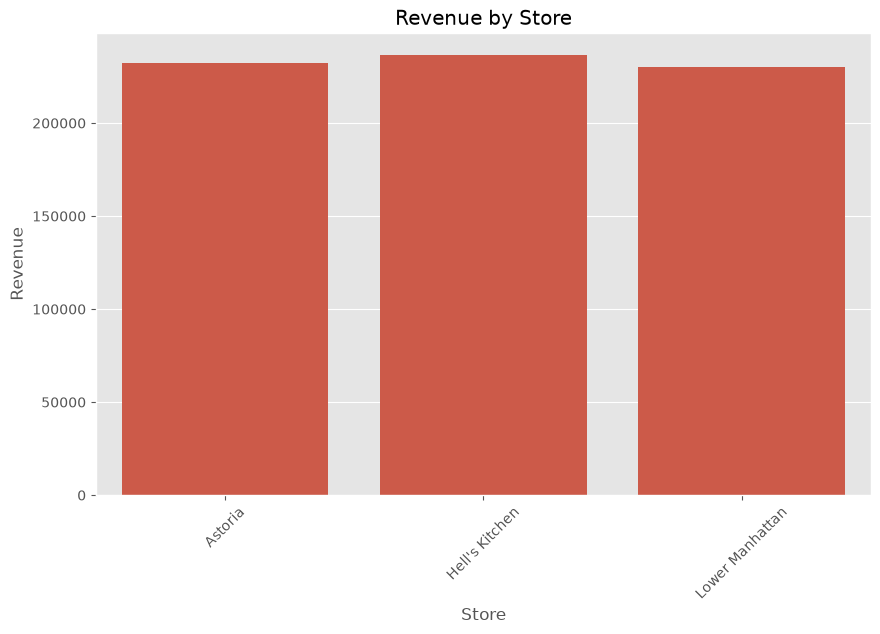

In [113]:
# Visualizing revenue by store
plt.figure(figsize=(10,6))

sns.barplot(
    x=revenue_by_store.index,
    y=revenue_by_store.values
)

plt.title("Revenue by Store")
plt.xlabel("Store")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

# REvenue by Product category

In [114]:
# checking revenue by product category
revenue_by_category = df.groupby('product_category')['Revenue'].sum()
print(revenue_by_category)

product_category
Bakery                 82315.64
Branded                13607.00
Coffee                269952.45
Coffee beans           40085.25
Drinking Chocolate     72416.00
Flavours                8408.80
Loose Tea              11213.60
Packaged Chocolate      4407.64
Tea                   196405.95
Name: Revenue, dtype: float64


/tmp/ipykernel_1889/2122663866.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


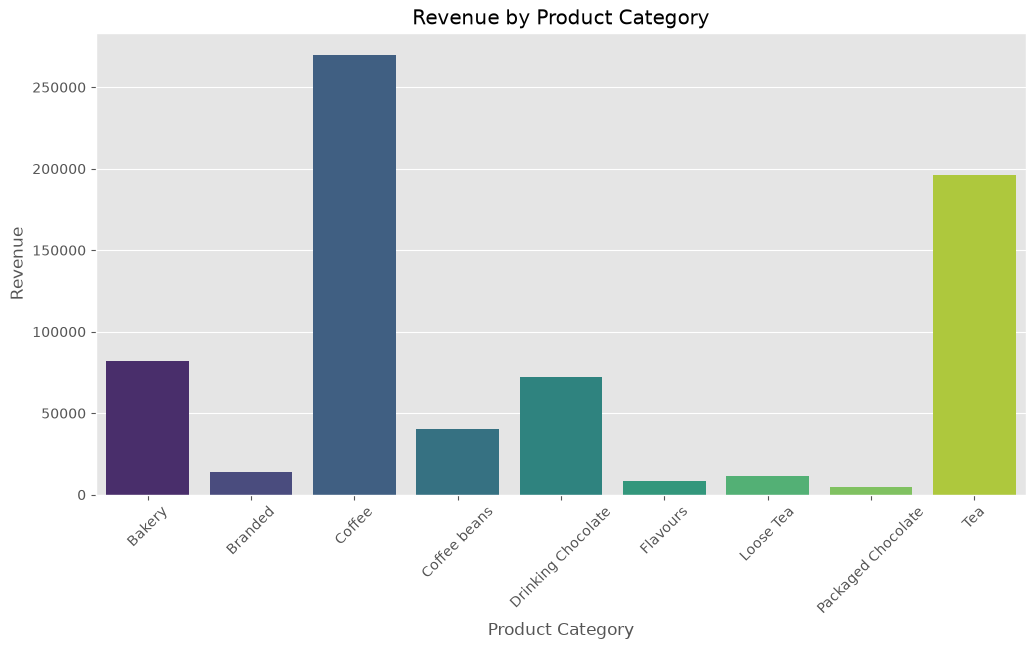

In [115]:
# visualizing revenue by product category
plt.figure(figsize=(12,6))
sns.barplot(
    x=revenue_by_category.index,
    y=revenue_by_category.values,
    palette="viridis"
)
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

# top 10 products by revenue

In [116]:
# top 10 products by revenue
top_10_products = df.groupby('product_category')['Revenue'].sum().sort_values(ascending=False).head(10)
print(top_10_products)

product_category
Coffee                269952.45
Tea                   196405.95
Bakery                 82315.64
Drinking Chocolate     72416.00
Coffee beans           40085.25
Branded                13607.00
Loose Tea              11213.60
Flavours                8408.80
Packaged Chocolate      4407.64
Name: Revenue, dtype: float64


/tmp/ipykernel_1889/1221683845.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0, 0.5, 'Revenue')

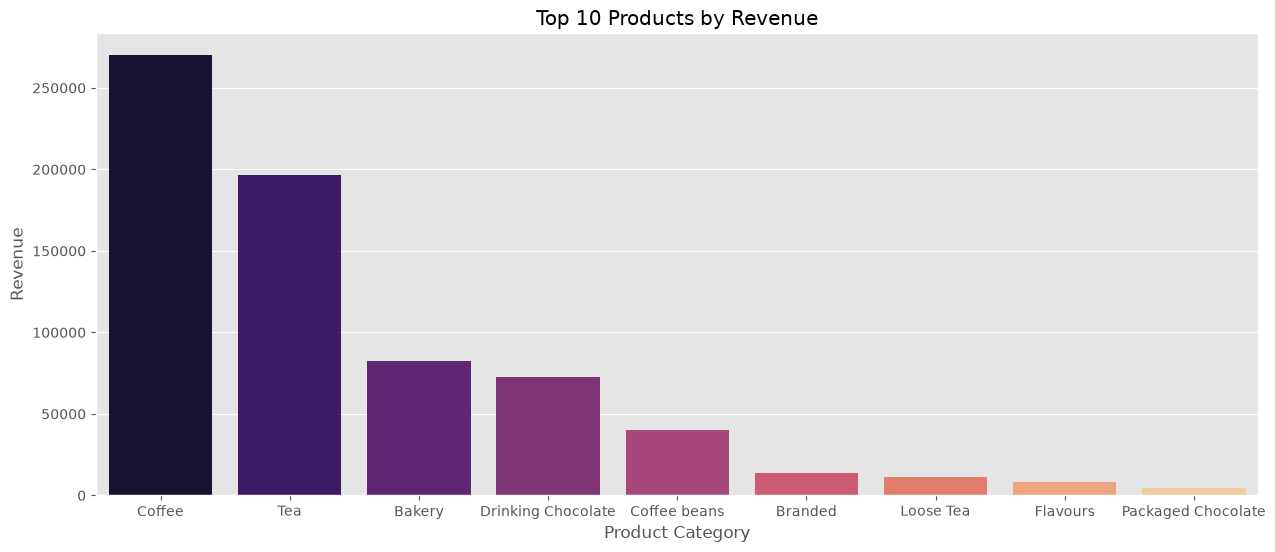

In [117]:
# visualizing top 10 products by revenue
plt.figure(figsize=(15,6))
sns.barplot(
    x=top_10_products.index,
    y=top_10_products.values,
    palette="magma"
)
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue")   

# Bottom 10 Products

In [118]:
# bottom 10 products by revenue
bottom_10_products = df.groupby('product_category')['Revenue'].sum().sort_values(ascending=True).head(10)
print(bottom_10_products)   

product_category
Packaged Chocolate      4407.64
Flavours                8408.80
Loose Tea              11213.60
Branded                13607.00
Coffee beans           40085.25
Drinking Chocolate     72416.00
Bakery                 82315.64
Tea                   196405.95
Coffee                269952.45
Name: Revenue, dtype: float64


/tmp/ipykernel_1889/1860364452.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0, 0.5, 'Revenue')

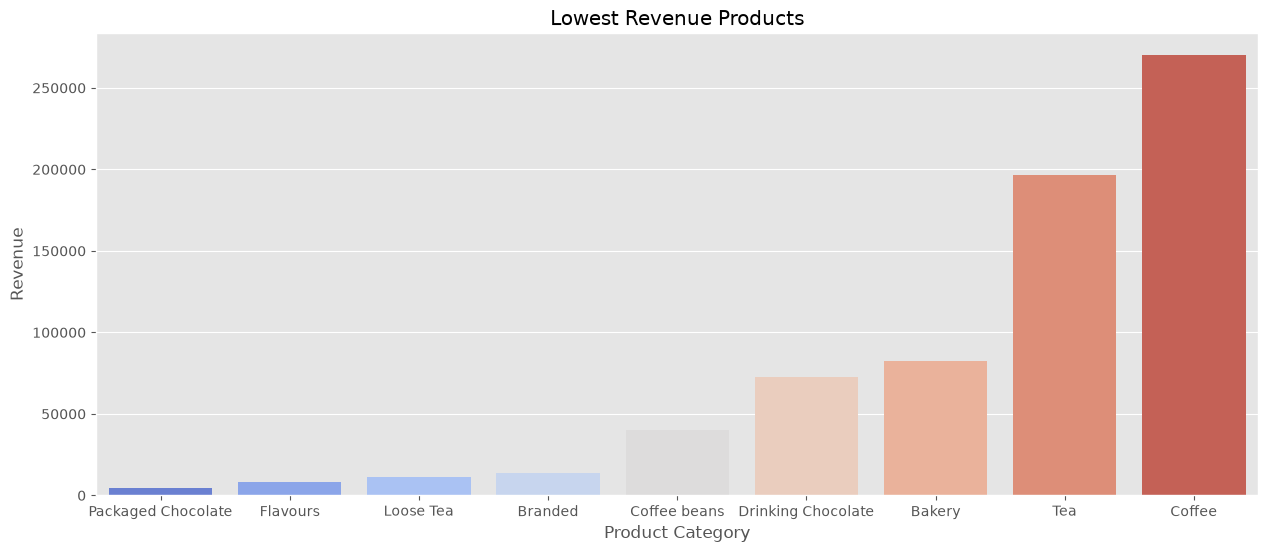

In [119]:
# visualizing bottom 10 products by revenue
plt.figure(figsize=(15,6))
sns.barplot(
    x=bottom_10_products.index,
    y=bottom_10_products.values,
    palette="coolwarm"
)
plt.title("Lowest Revenue Products")
plt.xlabel("Product Category")
plt.ylabel("Revenue")   

In [120]:
# hourly revenue
hourly_revenue = df.groupby('Hour')['Revenue'].sum()
print(hourly_revenue)


Hour
6     21900.27
7     63526.47
8     82699.87
9     85169.53
10    88673.39
11    46319.14
12    40192.79
13    40367.45
14    41304.74
15    41733.10
16    41122.75
17    40134.31
18    34286.20
19    28446.68
20     2935.64
Name: Revenue, dtype: float64


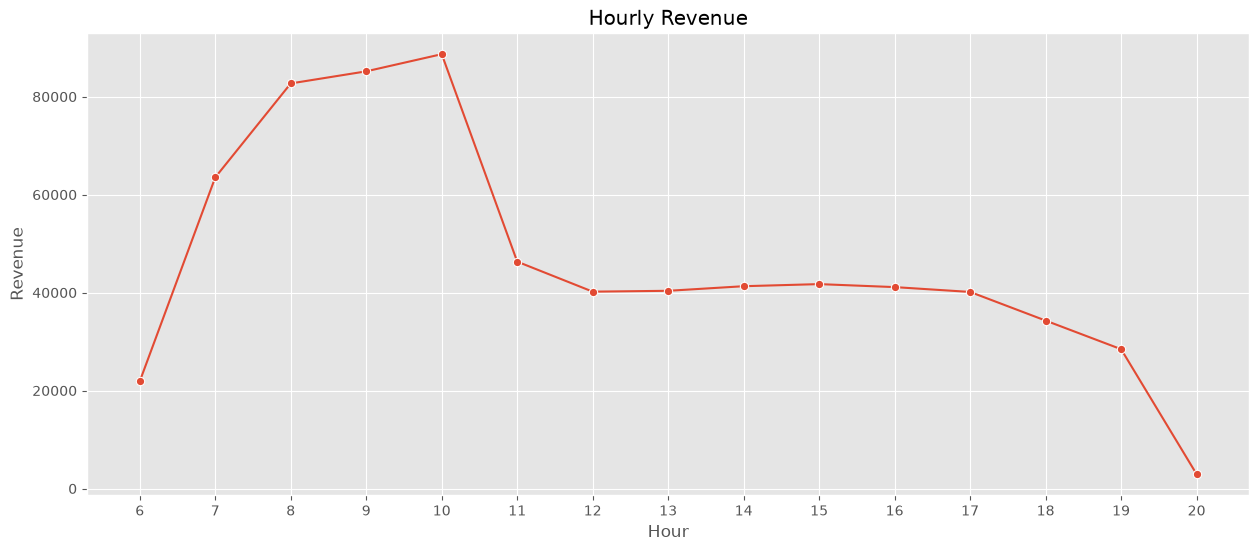

In [121]:
# visualizing hourly revenue
plt.figure(figsize=(15,6))
sns.lineplot(
    x=hourly_revenue.index.astype(str),
    y=hourly_revenue.values,
    marker='o'
)
plt.title("Hourly Revenue")
plt.xlabel("Hour")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()



In [122]:
# hourly transaction
hourly_transactions = df.groupby('Hour')['transaction_id'].count()
print(hourly_transactions)

Hour
6      4594
7     13428
8     17654
9     17764
10    18545
11     9766
12     8708
13     8714
14     8933
15     8979
16     9093
17     8745
18     7498
19     6092
20      603
Name: transaction_id, dtype: int64


Text(0, 0.5, 'Number of Transactions')

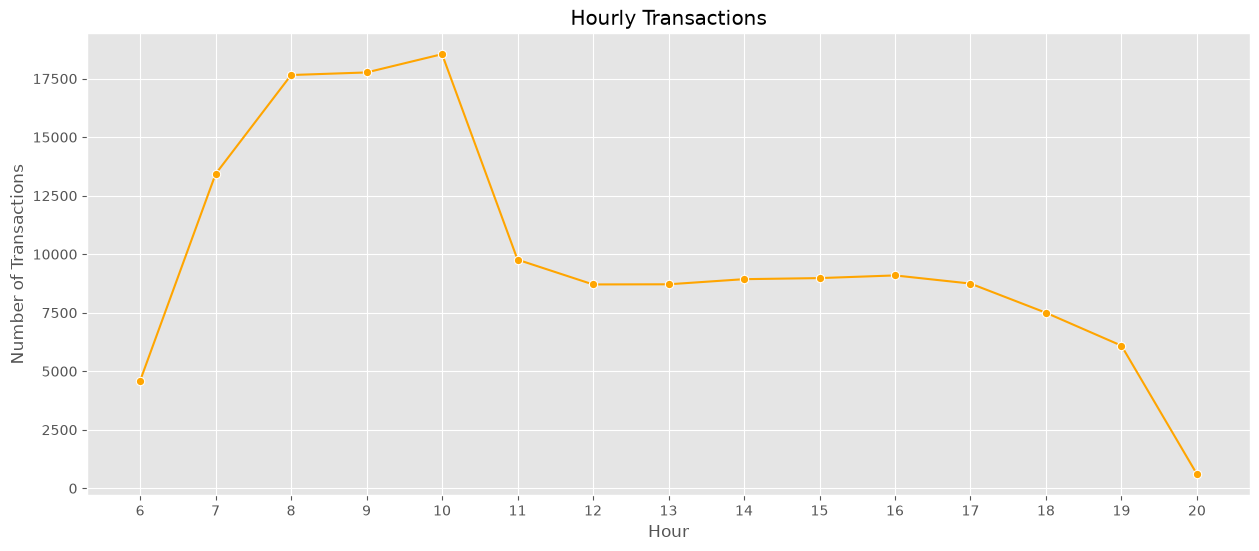

In [123]:
# visualizing of hourly transactions
plt.figure(figsize=(15,6))
sns.lineplot(
    x=hourly_transactions.index.astype(str),
    y=hourly_transactions.values,
    marker='o',
    color='orange'
)
plt.title("Hourly Transactions")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")

In [124]:
# quantity of transactions per hour
hourly_quantity = df.groupby('Hour')['transaction_qty'].sum()
print(hourly_quantity)

Hour
6      6865
7     19449
8     25197
9     25370
10    26713
11    14035
12    12690
13    12439
14    12907
15    12923
16    12881
17    12700
18    10826
19     8595
20      880
Name: transaction_qty, dtype: int64


Text(0, 0.5, 'Quantity of Transactions')

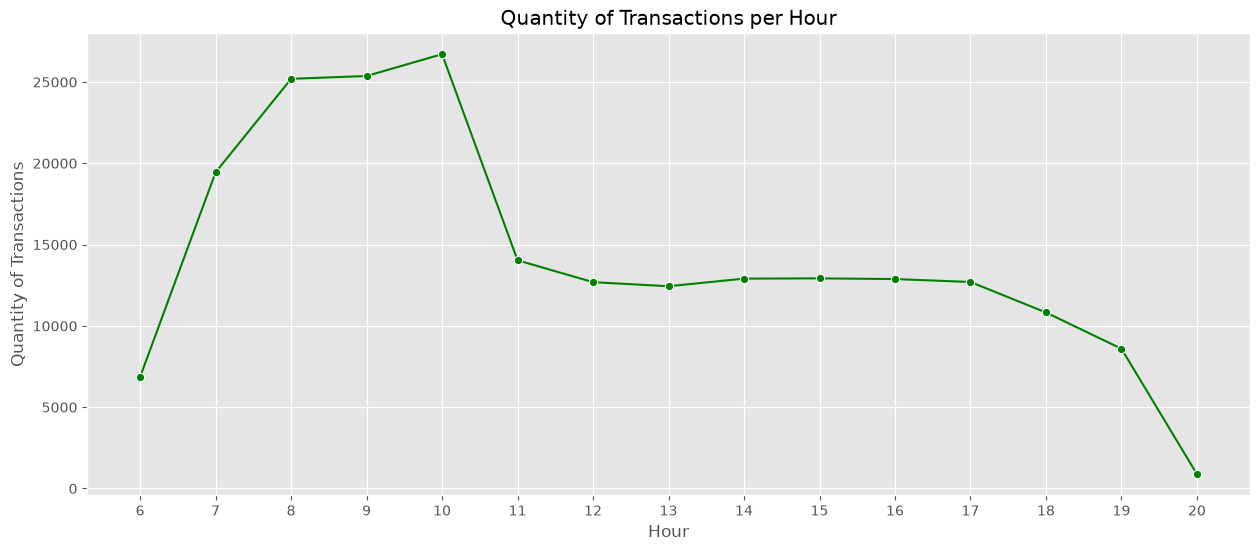

In [125]:
# visualizing quantity of transactions per hour
plt.figure(figsize=(15,6))
sns.lineplot(
    x=hourly_quantity.index.astype(str),
    y=hourly_quantity.values,
    marker='o',
    color='green'
)
plt.title("Quantity of Transactions per Hour")
plt.xlabel("Hour")
plt.ylabel("Quantity of Transactions")  

In [126]:
# time bucket analysis
time_bucket_revenue = df.groupby('Time Bucket')['Revenue'].sum()
print(time_bucket_revenue)

Time Bucket
Afternoon    204720.83
Evening      105802.83
Morning      388288.67
Name: Revenue, dtype: float64


/tmp/ipykernel_1889/887511888.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0, 0.5, 'Revenue')

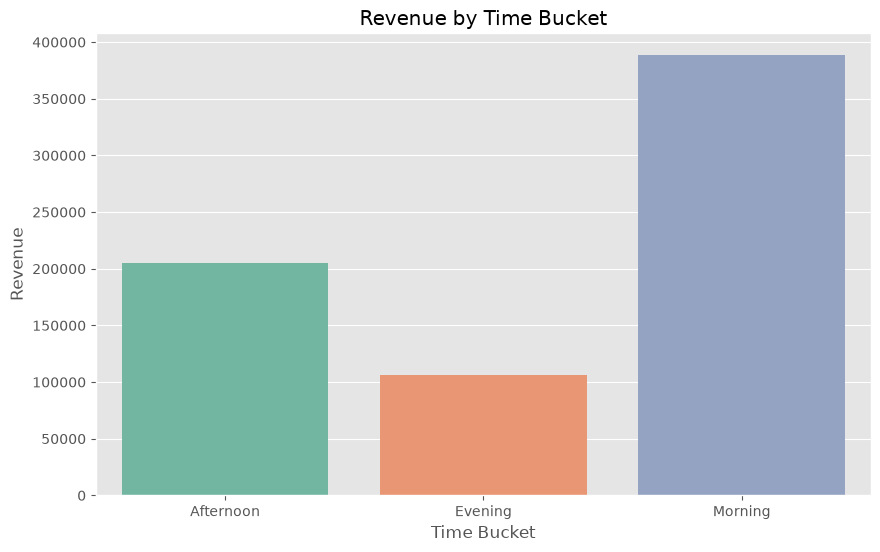

In [127]:
# visualizing  time bucket analysis
plt.figure(figsize=(10,6))
sns.barplot(
    x=time_bucket_revenue.index,
    y=time_bucket_revenue.values,
    palette="Set2"
)
plt.title("Revenue by Time Bucket")
plt.xlabel("Time Bucket")
plt.ylabel("Revenue")   

In [128]:
# revenue by store and time bucket
revenue_by_store_time_bucket = df.groupby(['store_location', 'Time Bucket'])['Revenue'].sum().unstack()
print(revenue_by_store_time_bucket)

Time Bucket      Afternoon   Evening    Morning
store_location                                 
Astoria           78567.14  48734.25  104942.52
Hell's Kitchen    59012.43  38055.44  139443.30
Lower Manhattan   67141.26  19013.14  143902.85


Text(0.5, 1.0, 'Revenue by Store and Time Bucket')

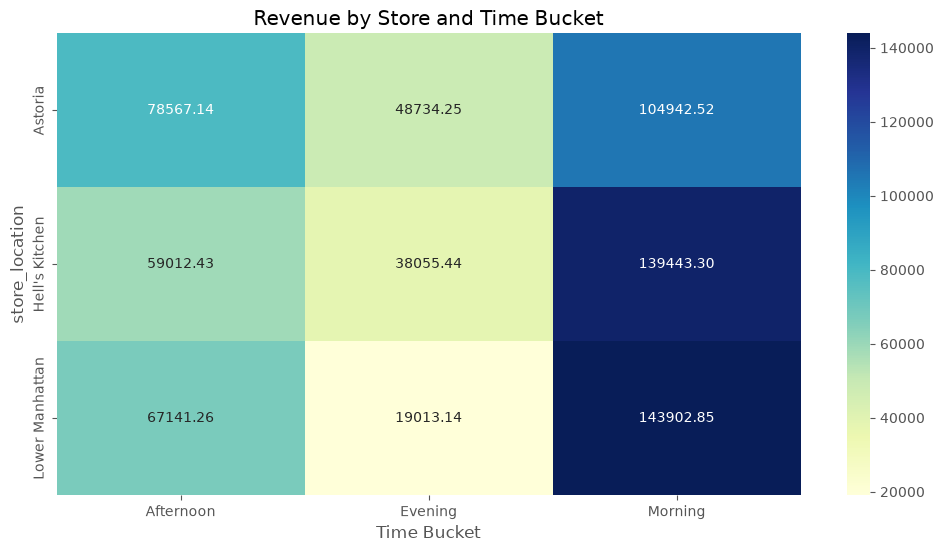

In [129]:
# visualizing revenue by store and time bucket
plt.figure(figsize=(12,6))
sns.heatmap(
    revenue_by_store_time_bucket,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)
plt.title("Revenue by Store and Time Bucket")   

Text(0.5, 0, 'Revenue')

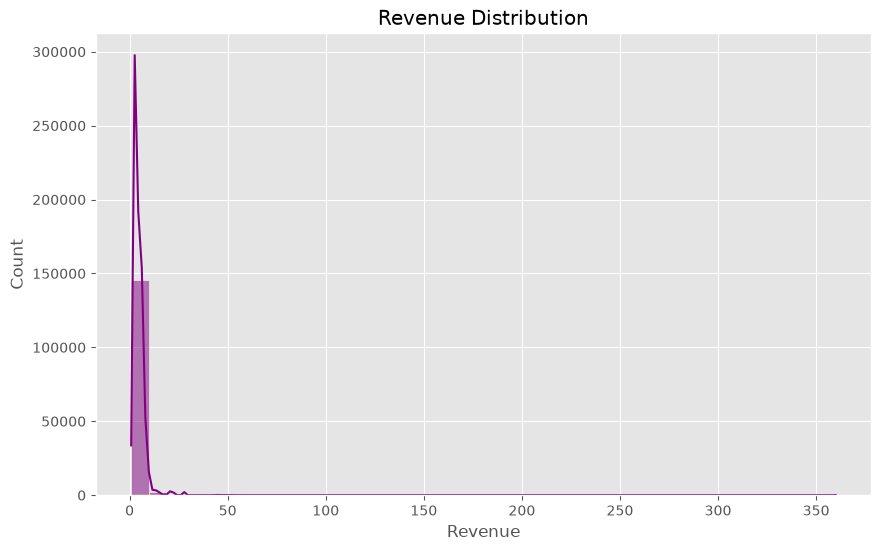

In [130]:
# revenue distribution
plt.figure(figsize=(10,6))
sns.histplot(
    df['Revenue'],
    bins=40,
    kde=True,
    color='purple'
)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")

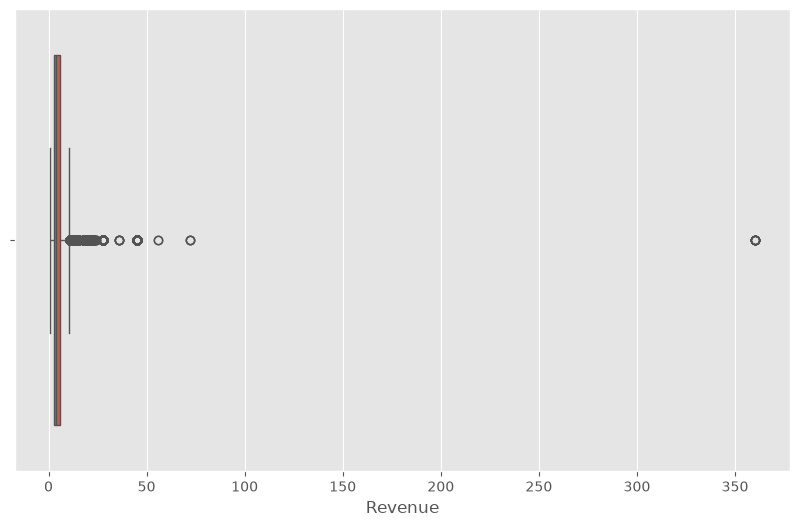

In [131]:
# visualizing revenue distribution using boxplot
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['Revenue']
)

plt.show()

In [132]:
# correlation analysis
corr = df[
    ['transaction_qty',
     'unit_price',
     'Revenue',
     'Hour']
].corr()

corr

,transaction_qty,unit_price,Revenue,Hour
transaction_qty,1.000000,-0.123546,0.356231,-0.006310
unit_price,-0.123546,1.000000,0.685550,-0.018435
Revenue,0.356231,0.685550,1.000000,-0.013783
Hour,-0.006310,-0.018435,-0.013783,1.000000


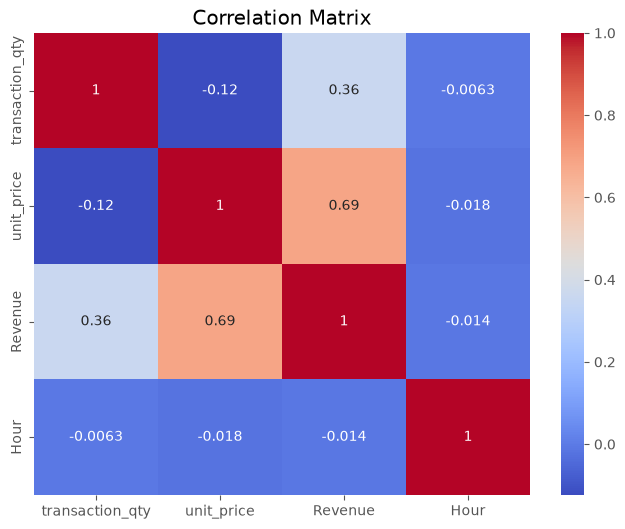

In [133]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [134]:
heat = df.pivot_table(
    values='Revenue',
    index='store_location',
    columns='Hour',
    aggfunc='sum'
)

heat.head()

Hour,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
store_location,,,,,,,,,,,,,,,
Astoria,NaN,19028.80,22805.90,23183.57,24426.12,15498.13,15681.20,15947.87,15175.27,15651.95,16110.85,15839.30,15951.30,16943.65,NaN
Hell's Kitchen,7531.17,15961.05,31544.44,32874.29,33605.81,17926.54,11343.10,12070.10,12297.50,11311.25,11990.48,12789.50,11863.21,10766.36,2636.37
Lower Manhattan,14369.10,28536.62,28349.53,29111.67,30641.46,12894.47,13168.49,12349.48,13831.97,14769.90,13021.42,11505.51,6471.69,736.67,299.27


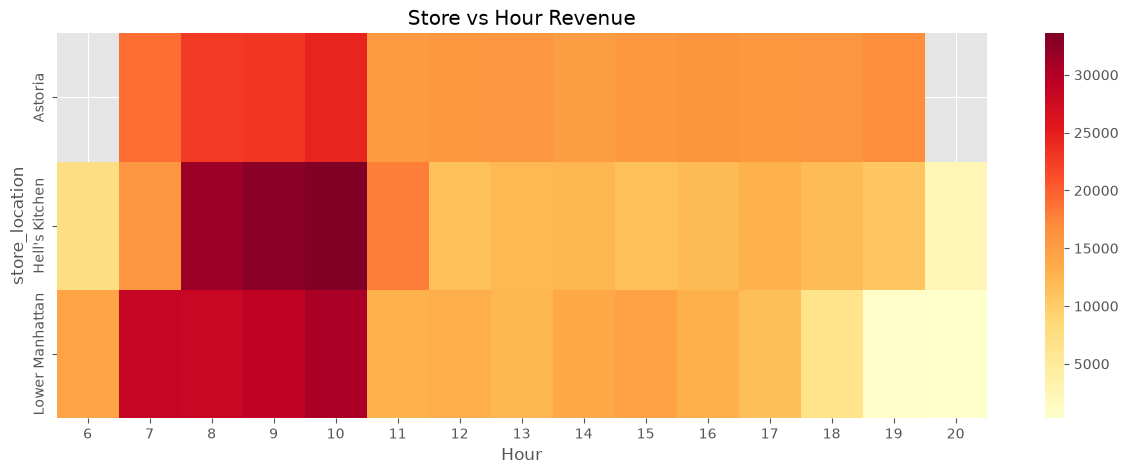

In [135]:
plt.figure(figsize=(15,5))

sns.heatmap(
    heat,
    cmap='YlOrRd'
)

plt.title("Store vs Hour Revenue")

plt.show()

In [139]:
fig = px.bar(
    x=revenue_by_store.index,
    y=revenue_by_store.values,
    labels={'x': 'store_location', 'y': 'Revenue'},
    title="Revenue by Store"
)

fig.show()


In [137]:
fig = px.line(
    hourly_revenue,
    title="Hourly Revenue"
)

fig.show()

In [140]:
print("Highest Revenue Store")
print(revenue_by_store.idxmax())

print()

print("Lowest Revenue Store")
print(revenue_by_store.idxmin())

print()

print("Peak Hour")
print(hourly_revenue.idxmax())

print()

print("Lowest Hour")
print(hourly_revenue.idxmin())

print()

print("Best Category")
print(revenue_by_category.idxmax())

Highest Revenue Store
Hell's Kitchen

Lowest Revenue Store
Lower Manhattan

Peak Hour
10

Lowest Hour
20

Best Category
Coffee
